# Colonel Blotto with adjacency bonuses

### Finding an approximate equilibrium with double oracle

Two players each place **100 soldiers** across **10 towers** worth 1–10 points. More soldiers
at a tower wins its points; a tie splits them. Two **adjacent** towers won outright (ties do
not count) award **5 bonus points**, and pairs overlap — three consecutive outright wins give 10.

---

**Method.** Solve a small restricted game by linear programming, use a dynamic program to find
each player's best response to it, add those responses to the restricted game, and repeat. The
gap between the two best-response values is *exploitability*: the same quantity an
exploitability calculator reports for a poker solver.

**How to read this.** Sections 1–3 run in a few seconds and show the method being validated on
games small enough to check by brute force. Sections 4–6 load the full-size results from
`results/`. The code lives in the modules beside this notebook and is covered by 125 tests in
`tests/`; every decision is logged with its reasoning in `DECISIONS.md`.

| | |
|---|---|
| **1** | The game and its payoff |
| **2** | Choosing an objective — the one real modeling decision |
| **3** | Validation: small games solved two ways |
| **4** | Full-size results and convergence |
| **5** | The discretization trap — the main finding |
| **6** | Choosing a single allocation to submit |

In [1]:
import json
from pathlib import Path

import numpy as np
from IPython.display import Markdown, display

from best_response import best_response, brute_force_best_response
from double_oracle import blotto_double_oracle
from ground_truth import solve_full_game
from payoff import GameConfig, col_weights, payoff, row_weights, score_components
from pick_allocation import HUMAN_OPPONENTS, score_support

RESULTS = Path("results")


def table(headers, rows, note=None):
    """Render a list of rows as a markdown table."""
    out = ["| " + " | ".join(headers) + " |",
           "|" + "|".join("---" for _ in headers) + "|"]
    out += ["| " + " | ".join(str(c) for c in row) + " |" for row in rows]
    if note:
        out.append("")
        out.append(note)
    display(Markdown("\n".join(out)))

## 1. The game and its payoff

`score_components(x, y, cfg)` returns four numbers: tower points and adjacency bonus for each
side. The example below is the one that drives the whole modeling decision — **both players
earn a bonus in the same game**.

In [2]:
four = GameConfig(n_towers=4, n_soldiers=8, unit=1)      # towers worth 1, 2, 3, 4
me, opp = np.array([3, 3, 1, 1]), np.array([0, 0, 4, 4])
T_me, B_me, T_opp, B_opp = score_components(me, opp, four)

table(
    ["", "allocation", "towers won", "tower points", "adjacency bonus", "total"],
    [["me",  list(me),  "1, 2",  T_me,  B_me,  T_me + B_me],
     ["opp", list(opp), "3, 4",  T_opp, B_opp, T_opp + B_opp]],
    note=(f"Tower points are constant-sum: **{T_me} + {T_opp} = {four.total_tower_points:.0f}**. "
          f"Bonuses are not: **{B_me} + {B_opp} = {B_me + B_opp}**, and either player can earn one."),
)

|  | allocation | towers won | tower points | adjacency bonus | total |
|---|---|---|---|---|---|
| me | [np.int64(3), np.int64(3), np.int64(1), np.int64(1)] | 1, 2 | 3.0 | 5.0 | 8.0 |
| opp | [np.int64(0), np.int64(0), np.int64(4), np.int64(4)] | 3, 4 | 7.0 | 5.0 | 12.0 |

Tower points are constant-sum: **3.0 + 7.0 = 10**. Bonuses are not: **5.0 + 5.0 = 10.0**, and either player can earn one.

## 2. Choosing an objective

Because bonuses are not constant-sum, *"maximize the points you earn"* is **not** a zero-sum
game — and linear programming needs one. Two zero-sum models are solved here.

Since tower points are constant-sum (`T_opp = 55 − T_me`), every objective can be written as
one weight vector:

$$\text{utility} = w_{\text{tower}} \cdot T_{\text{me}} + w_{\text{own}} \cdot B_{\text{me}} + w_{\text{opp}} \cdot B_{\text{opp}} + c$$

| model | $w_{\text{tower}}$ | $w_{\text{own}}$ | $w_{\text{opp}}$ | what it answers |
|---|---|---|---|---|
| **margin** | 2 | 1 | −1 | *By how much do I beat my opponent?* Symmetric, so its value must be **0**. |
| **security** | 1 | 1 | 0 | *How many points can I guarantee* against an opponent trying to hold me down? |

**Why margin's tower weight is 2.** Expanding the margin gives
$2T_{\text{me}} + B_{\text{me}} - B_{\text{opp}} - 55$, i.e. $\propto T_{\text{me}} + (B_{\text{me}} - B_{\text{opp}})/2$.
Taking a tower worth $v$ swings the margin by $2v$ — I gain it and you lose it — while my
bonus only moves it by 5, because it doesn't come out of your score. So relative to the
literal objective, margin prices a bonus at **half** as much and prices *blocking* the
opponent's bonus at exactly as much as earning my own. That single sentence is the entire
difference between the model and the question as written.

One dynamic program serves both models (and the "spiteful" opponent in the security game)
because the weights are folded into its lookup tables.

## 3. Validation

Nothing is trusted at full size before it matches a known answer on a small game — the same
ladder as Kuhn and Leduc poker for a CFR solver.

**Rung 1.** With 3 towers and 6 soldiers there are only 28 allocations, so the entire payoff
matrix can be built and handed to the LP. Double oracle must reproduce that value.

In [3]:
tiny = GameConfig(n_towers=3, n_soldiers=6, unit=1)

rows = []
for objective in ("margin", "security"):
    truth = solve_full_game(tiny, objective)
    do = blotto_double_oracle(tiny, objective, tol=1e-9)
    rows.append([objective, f"{truth.value:.6f}", f"{do.value:.6f}",
                 "yes" if abs(truth.value - do.value) < 1e-6 else "NO",
                 f"{len(do.history)}"])

table(["objective", "full LP (28x28)", "double oracle", "agree", "DO iterations"], rows,
      note=(f"The {tiny.n_pure_strategies} allocations are enumerated for the LP; double oracle "
            "never sees more than a handful at a time. **Margin is exactly 0** — swapping the "
            "players negates the payoff, so the value must equal its own negative."))

| objective | full LP (28x28) | double oracle | agree | DO iterations |
|---|---|---|---|---|
| margin | -0.000000 | -0.000000 | yes | 18 |
| security | 3.547291 | 3.547291 | yes | 19 |

The 28 allocations are enumerated for the LP; double oracle never sees more than a handful at a time. **Margin is exactly 0** — swapping the players negates the payoff, so the value must equal its own negative.

**Rung 2.** The dynamic program must reproduce brute force. On a 5-tower game there are 1,001
allocations, so the best response can be found by trying every one of them — for all three
weight settings, against a mixed opponent.

In [4]:
five = GameConfig(n_towers=5, n_soldiers=10, unit=1)
rng = np.random.default_rng(0)
opp_mix = np.array([rng.multinomial(five.n_units, np.full(5, 0.2)) for _ in range(4)])
mix_probs = rng.dirichlet(np.ones(4))

rows = []
for name, w in [("margin", row_weights("margin", five)),
                ("security (row)", row_weights("security", five)),
                ("security (column)", col_weights("security", five))]:
    x_dp, v_dp = best_response(opp_mix, mix_probs, five, w)
    _, v_brute = brute_force_best_response(opp_mix, mix_probs, five, w)
    rows.append([name, f"{v_dp:.6f}", f"{v_brute:.6f}",
                 "yes" if abs(v_dp - v_brute) < 1e-9 else "NO", list(x_dp)])

table(["weights", "DP", "brute force (1,001)", "agree", "DP's allocation"], rows)

| weights | DP | brute force (1,001) | agree | DP's allocation |
|---|---|---|---|---|
| margin | 12.841770 | 12.841770 | yes | [np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(0)] |
| security (row) | 19.035808 | 19.035808 | yes | [np.int64(4), np.int64(2), np.int64(2), np.int64(2), np.int64(0)] |
| security (column) | -5.198982 | -5.198982 | yes | [np.int64(0), np.int64(1), np.int64(0), np.int64(2), np.int64(7)] |

### How the best response works

Scoring an allocation splits into terms that each involve **one tower** (its points) or **two
neighbouring towers** (the adjacency bonus). The opponent's whole mixture is collapsed once
into two lookup tables — `tower_value[i, a]` and `pair[i, a, b]`, with the objective's weights
folded in — and then the DP walks the towers left to right:

$$f(i, r, p) = \max_{a \le r} \; \text{tower_value}[i, a] \; + \; \text{pair}[i-1, p, a] \; + \; f(i+1, r-a, a)$$

where **i** is the tower, **r** the units still unspent, and **p** the count placed on the
previous tower. Carrying **p** is what makes the adjacency bonus expressible: the pair
$(i-1, i)$ is paid at the moment tower $i$ is chosen. Cost is $n \cdot U^3$, so the ~10 million
allocations are never enumerated.

> **A subtlety worth stating.** $P(\text{win both towers}) \ne P(\text{win } i) \cdot P(\text{win } i{+}1)$.
> The opponent's towers come from a *single* allocation, so soldiers spent on one are not
> available for the other. The joint probabilities are summed over their support directly.
> Treating the towers as independent would make the solver chase bonuses that aren't there.

## 4. Full-size results

Produced by `run.py`, which saves to `results/`:

```bash
python run.py --objective margin   --unit 5 --fine-check
python run.py --objective security --unit 1 --fine-check
```

`unit` is the soldier granularity: units of 5 means soldiers move in blocks of 5 (~10 million
allocations), while units of 1 is the game exactly as asked (~4 x 10^12 allocations).

In [5]:
runs = {p.stem: json.loads(p.read_text()) for p in sorted(RESULTS.glob("*.json"))}
if not runs:
    display(Markdown("*No results yet — run the commands above first.*"))

rows = []
for name, r in runs.items():
    rows.append([
        r["objective"], r["unit"], f"{r['value']:.4f}", r["iterations"], r.get("support", "—"),
        f"{r.get('solve_seconds', 0):.0f}s",
        "yes" if r.get("converged") else f"gap {r['history'][-1]['gap']:.3f}",
        f"{r['fine_br_value']:.4f}" if "fine_br_value" in r else "—",
        f"**{r['fine_exploitability']:.2f}**" if "fine_exploitability" in r else "—",
    ])

table(["objective", "unit", "value", "iterations", "support", "time", "converged",
       "held to, at 1 soldier", "exploitability"], rows,
      note=("*support* is how many allocations the equilibrium actually plays. The last two "
            "columns replay the strategy in the **1-soldier** game and ask what an "
            "unconstrained opponent can do to it — see section 5."))

| objective | unit | value | iterations | support | time | converged | held to, at 1 soldier | exploitability |
|---|---|---|---|---|---|---|---|---|
| margin | 5 | -0.0000 | 445 | 179 | 120s | yes | -18.5701 | **18.57** |
| security | 5 | 35.9982 | 205 | 53 | 21s | yes | 30.7104 | **5.29** |

*support* is how many allocations the equilibrium actually plays. The last two columns replay the strategy in the **1-soldier** game and ask what an unconstrained opponent can do to it — see section 5.

### Convergence

The gap is `row_br_value − col_br_value`: what the two players *together* would gain by
deviating from the current restricted equilibrium. When it reaches zero, neither player has
anything left to add, so the restricted equilibrium is an equilibrium of the **full** game.

Matplotlib is building the font cache; this may take a moment.


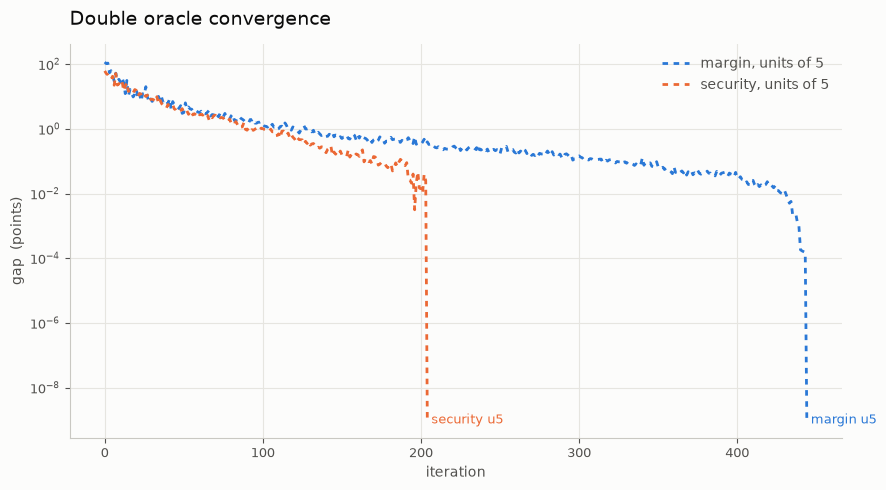

In [6]:
import matplotlib.pyplot as plt

SURFACE, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e0"
COLORS = {"margin": "#2a78d6", "security": "#eb6834"}
STYLES = {5: (2, 2), 2: (5, 2), 1: ()}          # dash pattern per discretization

fig, ax = plt.subplots(figsize=(9, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

for name, r in runs.items():
    gaps = [max(rec["gap"], 1e-9) for rec in r["history"]]
    line, = ax.plot(range(len(gaps)), gaps, linewidth=2, color=COLORS[r["objective"]],
                    label=f"{r['objective']}, units of {r['unit']}")
    if STYLES.get(r["unit"]):
        line.set_dashes(STYLES[r["unit"]])
    ax.annotate(f" {r['objective']} u{r['unit']}", (len(gaps) - 1, gaps[-1]),
                color=COLORS[r["objective"]], fontsize=9, va="center")

ax.set_yscale("log")
ax.set_xlabel("iteration", color=MUTED, fontsize=10)
ax.set_ylabel("gap  (points)", color=MUTED, fontsize=10)
ax.set_title("Double oracle convergence", color=INK, loc="left", fontsize=14, pad=14)
ax.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("#c9c8c2")
ax.tick_params(colors=MUTED, labelsize=9)
ax.legend(frameon=False, labelcolor=MUTED, fontsize=10)
plt.tight_layout()
plt.show()

## 5. The discretization trap

**This is the main finding.**

The first full run placed soldiers in units of 5. Inside that game double oracle converged to
a gap of 0 — an exact equilibrium, certified. But both players there are confined to multiples
of 5, and a real opponent is not.

`exploitability.py` replays the solved strategy in the **1-soldier** game and asks the DP for
the best response to it. Look at the allocation it finds:

In [7]:
rows = []
for name, r in runs.items():
    if "fine_br_alloc" in r:
        rows.append([r["objective"], r["unit"], f"{r['value']:.4f}",
                     f"{r['fine_br_value']:.4f}", f"**{r['fine_exploitability']:.2f}**",
                     r["fine_br_alloc"]])

table(["objective", "solved at unit", "its own value", "held to, at 1 soldier",
       "gives up", "the exploiting allocation"], rows,
      note=("Almost every entry is **one more than a multiple of 5**. A strategy that only "
            "ever plays multiples of 5 loses nearly every tower to an opponent who adds a "
            "single soldier — and the coarse game cannot represent that move, so its gap of "
            "0 said nothing about it."))

| objective | solved at unit | its own value | held to, at 1 soldier | gives up | the exploiting allocation |
|---|---|---|---|---|---|
| margin | 5 | -0.0000 | -18.5701 | **18.57** | [1, 11, 11, 16, 6, 21, 26, 1, 6, 1] |
| security | 5 | 35.9982 | 30.7104 | **5.29** | [6, 1, 1, 1, 1, 1, 36, 1, 41, 11] |

Almost every entry is **one more than a multiple of 5**. A strategy that only ever plays multiples of 5 loses nearly every tower to an opponent who adds a single soldier — and the coarse game cannot represent that move, so its gap of 0 said nothing about it.

> **The lesson.** A convergence gap only certifies a strategy against deviations the model can
> represent. The honest number is the one measured in the game actually being played — which is
> why the final answer is solved at 1-soldier resolution, and why exploitability is reported
> there rather than in the grid that produced it.

## 6. Choosing a single allocation

The question asks for *one* allocation, but the equilibrium is a mixture — and Blotto has no
pure equilibrium, so every fixed allocation has a counter. Two facts make the choice
manageable:

1. **Randomizing is the only unexploitable answer**, and its guarantee holds in a single game,
   because it is a guarantee on the *expected* score. Playing a mixed strategy once means
   drawing one allocation from it.
2. **Every allocation in the support scores the game value** against an equilibrium opponent.
   So choosing among them costs nothing against a perfect opponent, and can only help against
   a human.

Below, each support allocation is scored against plausible human submissions. The
`vs eq` column is the check on fact 2: it should equal the game value for every row.

In [8]:
best = runs.get("margin_unit1") or runs.get("margin_unit2") or runs.get("margin_unit5")
rows = score_support(best["allocations"], best["probs"], best["objective"])
names = list(HUMAN_OPPONENTS)

table(["allocation", "prob", "avg vs field", "worst case", "vs eq"] + names,
      [[str(r["alloc"]), f"{r['prob']:.4f}", f"**{r['avg']:.2f}**", f"{r['worst']:.2f}",
        f"{r['vs_equilibrium']:.3f}"] + [f"{r['per_opponent'][n]:.1f}" for n in names]
       for r in rows[:10]],
      note=f"Top 10 of {len(rows)} support allocations, solved at units of {best['unit']}, "
           f"ranked by average margin against the field below.")

table(["opponent", "allocation", "idea"],
      [[n, str(a), d] for (n, a), d in zip(HUMAN_OPPONENTS.items(), [
          "spread evenly", "concede the cheap towers", "soldiers in proportion to value",
          "give up towers 1-3", "five-tower block, chasing bonuses", "buy the three best towers"])])

| allocation | prob | avg vs field | worst case | vs eq | even | top_heavy | proportional | abandon_small | bonus_cluster | top_three_only |
|---|---|---|---|---|---|---|---|---|---|---|
| [0, 5, 5, 5, 10, 15, 20, 20, 20, 0] | 0.0070 | **23.17** | 10.00 | 0.000 | 10.0 | 28.0 | 42.0 | 31.0 | 13.0 | 15.0 |
| [0, 0, 10, 0, 15, 15, 20, 20, 20, 0] | 0.0072 | **17.67** | -8.00 | -0.000 | 33.0 | 7.0 | 36.0 | 44.0 | -8.0 | -6.0 |
| [5, 5, 5, 10, 10, 20, 0, 0, 20, 25] | 0.0033 | **16.33** | -6.00 | -0.000 | -6.0 | 12.0 | 37.0 | 21.0 | 25.0 | 9.0 |
| [5, 5, 15, 15, 15, 15, 25, 0, 0, 5] | 0.0022 | **13.83** | -1.00 | 0.000 | 0.0 | 21.0 | 21.0 | 21.0 | -1.0 | 21.0 |
| [0, 0, 5, 0, 10, 25, 20, 20, 20, 0] | 0.0005 | **12.83** | -6.00 | -0.000 | 10.0 | 7.0 | 33.0 | 24.0 | 9.0 | -6.0 |
| [5, 5, 5, 5, 5, 20, 25, 0, 30, 0] | 0.0002 | **12.67** | -26.00 | 0.000 | -26.0 | 34.0 | 3.0 | 11.0 | 33.0 | 21.0 |
| [0, 5, 5, 5, 10, 0, 5, 20, 25, 25] | 0.0052 | **11.67** | -6.00 | 0.000 | -6.0 | 11.0 | 21.0 | 10.0 | 35.0 | -1.0 |
| [0, 10, 5, 5, 10, 0, 25, 0, 20, 25] | 0.0045 | **11.67** | -1.00 | 0.000 | 4.0 | 8.0 | 19.0 | 8.0 | 32.0 | -1.0 |
| [5, 5, 5, 5, 5, 25, 20, 25, 5, 0] | 0.0164 | **10.83** | -28.00 | 0.000 | -28.0 | 32.0 | 1.0 | 9.0 | 30.0 | 21.0 |
| [5, 10, 10, 10, 10, 0, 25, 25, 0, 5] | 0.0057 | **10.83** | -11.00 | 0.000 | -11.0 | 25.0 | 25.0 | -4.0 | 25.0 | 5.0 |

Top 10 of 179 support allocations, solved at units of 5, ranked by average margin against the field below.

| opponent | allocation | idea |
|---|---|---|
| even | [10, 10, 10, 10, 10, 10, 10, 10, 10, 10] | spread evenly |
| top_heavy | [0, 0, 0, 0, 5, 10, 15, 20, 25, 25] | concede the cheap towers |
| proportional | [2, 4, 5, 7, 9, 11, 13, 15, 16, 18] | soldiers in proportion to value |
| abandon_small | [0, 0, 0, 10, 12, 14, 16, 16, 16, 16] | give up towers 1-3 |
| bonus_cluster | [0, 0, 0, 0, 0, 20, 20, 20, 20, 20] | five-tower block, chasing bonuses |
| top_three_only | [0, 0, 0, 0, 0, 0, 0, 30, 35, 35] | buy the three best towers |

## What this produces

- An approximate equilibrium with a **certified** exploitability, measured in the real
  1-soldier game rather than in the grid used to compute it.
- A single allocation to submit, chosen from the equilibrium's support, with the tradeoff
  stated: drawing at random is unexploitable even against an opponent who knows the method,
  while choosing deliberately trades that last protection for an edge against how people
  actually play.

**Repository:** `payoff.py` (game and objectives) · `lp_solver.py` (zero-sum LP) ·
`best_response.py` (the DP) · `double_oracle.py` (the loop) · `ground_truth.py` (exact small
games) · `exploitability.py` (the fine-grid check) · `tests/` (125 tests) ·
`DECISIONS.md` (every decision and why).